# Theory runner — universal `compute_cumulants` front-end

Loads **any** theory from `theories/*.theory.py` and runs the full pipeline against it through the shared [`daedalus.py`](daedalus.py) engine — one notebook works for every theory: temporal or spatial, single- or multi-field, any `k`, any loop order, with or without Dyson dressing.

**Workflow:** pick a theory → set one `dd.Config` → run → inspect → plot → (optionally) save.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import daedalus as dd
print('daedalus \u2192', dd.REPO_ROOT)

daedalus → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Pick a theory

Every `theories/<name>.theory.py` is loadable by `<name>`.  The list grows automatically as you save new theories from [`theory_builder.ipynb`](theory_builder.ipynb).

In [2]:
for _n in dd.list_theories():
    print(' ', _n)

  allen_cahn_1d_subcritical_infinite
  allen_cahn_1d_subcritical_pbc
  allen_cahn_quintic_1d_subcritical_infinite
  burgers_1d
  coupled_rd_2species_1d
  edwards_wilkinson_1d
  kpz_1d
  linear_diffusion_test
  linear_hawkes
  multipopulation_spike_reset_test
  multipopulation_test
  my_stochastic_theory
  ou_quartic_colored
  ou_quartic_double_well
  ou_quartic_two_dim
  ou_quartic_two_dim_color_corr
  ou_quartic_two_dim_corr
  ou_sextic
  quadratic_hawkes
  reaction_diffusion_conserved_1d
  reaction_diffusion_quadratic_1d
  single_pop_dendritic_linear
  single_population_bistable_demo
  single_population_conductance_synapse_test
  single_population_conductance_test
  single_population_cubic_alpha_test
  single_population_linear_conductance_test
  single_population_linear_delta_spikes_test
  single_population_linear_delta_voltage_test
  single_population_linear_exp_voltage_test
  single_population_quad_exp_test
  single_population_quad_spike_reset_test
  single_population_spike_reset_t

## 3. Configure the run

One `dd.Config` holds everything.  Leave a field `None` to inherit the theory file's `METADATA` / `DEFAULT_FUNDAMENTAL`.  All knobs are shown below — most runs only need `k` and `max_ell`.

In [3]:
THEORY = 'ou_quartic_double_well'   # any name printed above

cfg = dd.Config(
    # --- what to compute (arbitrary k and loop order) ---
    k=2,            # correlator order: 2 = ⟨··⟩, 3 = ⟨···⟩, …
    max_ell=1,      # loop order: 0 = tree, 1 = +1-loop, …
    # external_fields=[('dx', 1), ('dx', 1)],  # None → auto from theory
    # fundamental={'mu': 1.0},                 # numeric param overrides

    # --- temporal grid (temporal theories) ---
    tau_max=None,   # None → theory METADATA default
    tau_step=None,

    # --- spatial (spatial theories) ---
    spatial_grid=None,      # (lo, hi, n) | array | None → default
    # spatial_points=...,   # k≥3: (n_pts, k-1, 2) of (x_j, τ_j) offsets

    # --- Dyson dressing (coupled unequal-diffusion spatial) ---
    # dyson_order=1,        # any order ≥ 0; None → leave theory policy
    # reference_diffusion=0.8,

    # --- plotting (adaptable) ---
    show_orders='cumulative',   # 'cumulative' | 'incremental' | 'total'
    logy=False,
)

## 4. Load the theory

In [4]:
model, mod = dd.load_theory(THEORY)
print('loaded :', model.get('name'))
print('fields :', dd.field_names(model),
      '| spatial_dim:', dd.spatial_dim(model),
      '| multi-field:', dd.is_multifield(model))
print('params :', [p['name'] for p in (model.get('parameters') or [])])

loaded : OU Quartic Double Well
fields : ['dx'] | spatial_dim: 0 | multi-field: False
params : ['xstar', 'mu', 'eps', 'D']


## 5. Run the pipeline

`dd.run` resolves the config against the theory defaults and calls `compute_cumulants` (mean-field solve → diagram enumeration → causal integration), dispatching temporal vs spatial and the k≥3 / Dyson paths automatically.

In [5]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))

theory : 'OU Quartic Double Well'
k      : 2    max_ell : 1
fields : ['dx']   spatial_dim : 0


## 6. Inspect the result

The result dict exposes the mean-field accessor (`mf`), the resolved parameters (`params`), the per-loop-order decomposition, and the diagram inventory.

In [6]:
mf = res.get('mf')
if mf is not None:
    print('Mean-field saddle:')
    for name in mf:
        print(f'  {name!r:8} = {mf[name]}')

_diags = res.get('diagrams')
if _diags is not None:                       # temporal: explicit list
    from collections import Counter
    by_ell = Counter(d['ell'] for d in _diags)
    print('\nDiagrams by loop order:',
          dict(sorted(by_ell.items())), ' total', len(_diags))
else:                                        # spatial: summed in integrator
    _si = res.get('spatial_info') or {}
    print('\n[spatial] integrated', _si.get('n_live_diagrams', '?'),
          'live diagram(s); max_ell =', _si.get('max_ell', '?'))

Mean-field saddle:
  'x'      = [0.0]

Diagrams by loop order: {0: 1, 1: 4}  total 5


## 7. Plot

`dd.plot_cumulant` auto-dispatches: C(τ) for temporal, equal-time C(x,0) (+ a C(x,τ) heatmap when a τ grid is present) for spatial k=2, and a per-event bar chart for spatial k≥3.  `cfg.show_orders` controls the per-loop-order overlay.

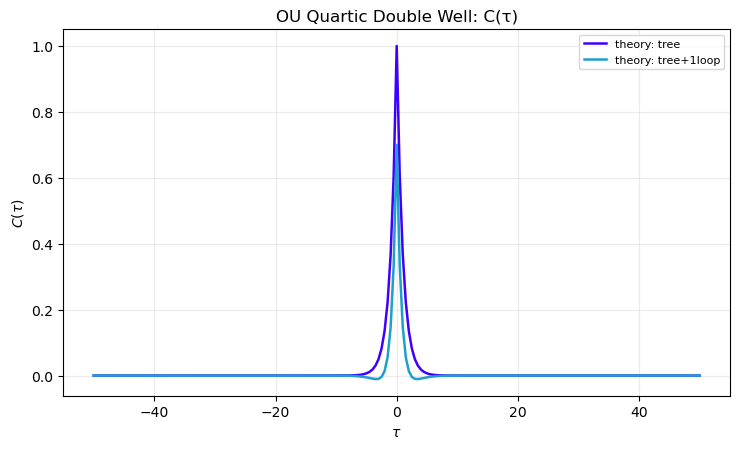

In [7]:
fig = dd.plot_cumulant(res, cfg, model)
plt.show()

## 8. Save outputs (optional)

Flip `SAVE` to write the result to `pipeline_outputs/<theory>/`.

In [8]:
SAVE = False
if SAVE:
    r = res['_resolved']
    out_dir = os.path.join(_root, 'pipeline_outputs', THEORY)
    os.makedirs(out_dir, exist_ok=True)
    slug = f"{THEORY}_k{r['k']}_ell{r['max_ell']}"
    dd.save_npz(res, os.path.join(out_dir, slug + '.npz'))
    dd.save_csv(res, os.path.join(out_dir, slug + '.csv'))
    print('saved', slug, 'to', out_dir)

---

### Want a different theory?

Change `THEORY` in section 3 to any name printed in section 2 and re-run.  To author a new theory, use the GUI in `theory_builder.ipynb` or the Python builder in `theory_builder_tutorial.ipynb`.